# Mini Project - COMP7019

### Predicting Airline passenger satisfaction

You are given a dataset that holds information from a passenger survey.
Your job is to build an ML model that can predict passenger satisfaction given information about their travel.

In preparing your work it is important to offer clear comments as observations. It is not only the technical work that is important, but what you observe in each step and how this guides your decisions on the steps you follow. The marking scheme is organised with specific marks for the correct technical work, but also for the comments and observations you make.
**Make sure you use 'Markdown' cells when you add your observations**

**Submission:** Submit your jupyter notebook file through moodle

#### Marking Scheme

Overall presentation and quality of notebook \[**5 marks**\]

Preparation \[Technical work: **10 marks**\, Observations: **5 marks**\]
- Investigation
- Data preprocessing - Cleaning - Encoding
- Statistical Analysis

Model selection \[Technical work: **15 marks**\, Observations: **10 marks**\]
- Data preparation / splitting
- Exploring alternative models and appropriate parameters
- Reporting on performance
- Adjustments to your overall approach based on observed results.

Finalising [**5 marks**]
- Final model selected and performance reported
- What aspects of the traveller's experience are important for their satisfaction?


\[**Total marks: 50**\]


#### Dataset

- Gender: Gender of the passengers (Female, Male) \[**Note:** *We recognise that gender may not be binary, however we reproduce the data as published by the US Airline passenger satisfaction survey.* \]
- Customer Type: The customer type (Loyal customer, disloyal customer)
- Age: The actual age of the passengers
- Type of Travel: Purpose of the flight of the passengers (Personal Travel, Business Travel)
- Class: Travel class in the plane of the passengers (Business, Eco, Eco Plus)
- Flight distance: The flight distance of this journey
- Inflight wifi service: Satisfaction level of the inflight wifi service (0:Not Applicable;1-5)
- Departure/Arrival time convenient: Satisfaction level of Departure/Arrival time convenient
- Ease of Online booking: Satisfaction level of online booking
- Gate location: Satisfaction level of Gate location
- Food and drink: Satisfaction level of Food and drink
- Online boarding: Satisfaction level of online boarding
- Seat comfort: Satisfaction level of Seat comfort
- Inflight entertainment: Satisfaction level of inflight entertainment
- On-board service: Satisfaction level of On-board service
- Leg room service: Satisfaction level of Leg room service
- Baggage handling: Satisfaction level of baggage handling
- Check-in service: Satisfaction level of Check-in service
- Inflight service: Satisfaction level of inflight service
- Cleanliness: Satisfaction level of Cleanliness
- Departure Delay in Minutes: Minutes delayed when departure
- Arrival Delay in Minutes: Minutes delayed when Arrival
- Satisfaction: Airline satisfaction level(Satisfaction, neutral or dissatisfaction)



# Preparation: Preamble, Data load/preprocessing, & Stasitcal Analysis

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import metrics 
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
#from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

In [2]:
df = pd.read_csv('dataset.csv')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129880 entries, 0 to 129879
Data columns (total 24 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   id                                 129880 non-null  int64  
 1   Gender                             129880 non-null  object 
 2   Customer Type                      129880 non-null  object 
 3   Age                                129880 non-null  int64  
 4   Type of Travel                     129880 non-null  object 
 5   Class                              129880 non-null  object 
 6   Flight Distance                    129880 non-null  int64  
 7   Inflight wifi service              129880 non-null  int64  
 8   Departure/Arrival time convenient  129880 non-null  int64  
 9   Ease of Online booking             129880 non-null  int64  
 10  Gate location                      129880 non-null  int64  
 11  Food and drink                     1298

In [4]:
df.head(5)

,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


In [5]:
# Creating a function to count the different categories within the object-labeled features
def show_object_counts(df):
    obj_cols = df.select_dtypes(include='object').columns
    
    for col in obj_cols:
        print(f"\n--- {col} ---")
        print(pd.concat([
            df[col].value_counts(),
            df[col].value_counts(normalize=True).round(3)
        ], axis=1, keys=['count', 'proportion']))

show_object_counts(df)


--- Gender ---
        count  proportion
Gender                   
Female  65899       0.507
Male    63981       0.493

--- Customer Type ---
                    count  proportion
Customer Type                        
Loyal Customer     106100       0.817
disloyal Customer   23780       0.183

--- Type of Travel ---
                 count  proportion
Type of Travel                    
Business travel  89693       0.691
Personal Travel  40187       0.309

--- Class ---
          count  proportion
Class                      
Business  62160       0.479
Eco       58309       0.449
Eco Plus   9411       0.072

--- satisfaction ---
                         count  proportion
satisfaction                              
neutral or dissatisfied  73452       0.566
satisfied                56428       0.434


#### Observations

The full dataset includes up to 129,880 non-null observations across 24 different feature variables with a majority (18 of 24) of the data types being integers with others being objects (5 of 24) or floats (1 of 24). Only one feature ('arrival delay in minutes') has a lower than full non-null count at 129,487 observations, a difference of 393 observations. This means that in order to fully process and build a workable model, there will need to be some sort of cleaning and reshaping of various features completed to ensure an ease of comparability across all features. The target variable of 'satisfaction' will be categorical and will later be encoded for classification. Similarly, there are categories that may not be useful for any model development, like 'id', so they can be removed before moving forward with further investigation/data engineering steps (such as one-hot encoding)

Because most service features are integer ratings and categorical variables are strings, I will treat numeric ratings as continuous predictors and apply one‑hot encoding to categorical variables; this informs my choice to use a ColumnTransformer for reproducible preprocessing. For the object-labeled / categorical features (Gender, Customer Type, Type of Travel, Class, & satisfaction), the show_object_counts function provides an output to better understand the balance within each of those feature categories before such cleaning occurs. This shows that of the original 129,880 observations, there are 65,899 females / 63,981 males (a near 50/50 percentage balance); more 106,100 loyal customers (81 percent); a higher percentage of business travel (~70 percent); a plurality of either business (48 percent) or economy (45 percent) class travelers; and a majority of neutral or dissatisfied customers (57 percent).

To put that into a stronger context, initial exploration shows that the dataset contains both loyal customers and disloyal customers, with loyal customers forming a larger portion of the dataset. This may reflect the airline’s frequent flyer base. The Type of Travel variable indicates that a significant proportion of passengers travel for business purposes, while others travel for personal reasons. This distinction is important because business travelers may have different expectations regarding service quality, punctuality, and comfort. Additionally, the Class variable shows passengers traveling in Economy, Economy Plus, and Business class. Since service levels differ between these classes, this feature may have a strong influence on passenger satisfaction. Overall, these categorical variables are expected to play an important role in predicting satisfaction, as they reflect both customer loyalty and travel context.

Because the target is categorical and the features are mostly numeric ratings, this naturally suggests starting with baseline classification models such as Logistic Regression and Decision Trees and/or Random Forests. From there, we can evaluate the produced models based on training-set data and use hyperparameter adjustments to tailor-develop the most appropriate model before running it against the test-set data.

Side note: An added bonus of running this function now is that we are given the unique values for each of the object-coded features, saving time/energy later if/when needing to recode and/or reshape them for model development.

In [6]:
df = df.drop(columns=['id'])

In [7]:
df.isna().sum().sort_values(ascending=False)

Arrival Delay in Minutes             393
Gender                                 0
Seat comfort                           0
Departure Delay in Minutes             0
Cleanliness                            0
Inflight service                       0
Checkin service                        0
Baggage handling                       0
Leg room service                       0
On-board service                       0
Inflight entertainment                 0
Online boarding                        0
Customer Type                          0
Food and drink                         0
Gate location                          0
Ease of Online booking                 0
Departure/Arrival time convenient      0
Inflight wifi service                  0
Flight Distance                        0
Class                                  0
Type of Travel                         0
Age                                    0
satisfaction                           0
dtype: int64

In [8]:
df = df.dropna(subset=['Arrival Delay in Minutes'])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 129487 entries, 0 to 129879
Data columns (total 23 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Gender                             129487 non-null  object 
 1   Customer Type                      129487 non-null  object 
 2   Age                                129487 non-null  int64  
 3   Type of Travel                     129487 non-null  object 
 4   Class                              129487 non-null  object 
 5   Flight Distance                    129487 non-null  int64  
 6   Inflight wifi service              129487 non-null  int64  
 7   Departure/Arrival time convenient  129487 non-null  int64  
 8   Ease of Online booking             129487 non-null  int64  
 9   Gate location                      129487 non-null  int64  
 10  Food and drink                     129487 non-null  int64  
 11  Online boarding                    129487 no

In [9]:
#Checking the counts & proportions after cleaning the data
show_object_counts(df)


--- Gender ---
        count  proportion
Gender                   
Female  65703       0.507
Male    63784       0.493

--- Customer Type ---
                    count  proportion
Customer Type                        
Loyal Customer     105773       0.817
disloyal Customer   23714       0.183

--- Type of Travel ---
                 count  proportion
Type of Travel                    
Business travel  89445       0.691
Personal Travel  40042       0.309

--- Class ---
          count  proportion
Class                      
Business  61990       0.479
Eco       58117       0.449
Eco Plus   9380       0.072

--- satisfaction ---
                         count  proportion
satisfaction                              
neutral or dissatisfied  73225       0.566
satisfied                56262       0.434


#### Observations





The ID column represents a unique identifier assigned to each passenger record. Since this variable does not contain meaningful information related to passenger behaviour or service experience, it does not contribute to predicting satisfaction. Including such an identifier in the model could introduce unnecessary noise and potentially reduce model performance. Therefore, the 'id' column is removed from the dataset before training the machine learning models.

After dropping 'id' and re-checking the df, I made the decision to drop all null values. This is because there is only one variable with nulls, (Arrival Delay in Minutes with 393 null values) and those nulls account for < 1% of the total observations. This reduces the dataset from 129,880 to 129,487 observations, equating to a 0.3% loss, which is negligible for model training. Were that number higher and/or more significant to the overall development of any developed model, I would have considered filling the missing rows by imputing the median value, but given the low overall percentage of impacted features and/or null values, this seemed unnecessary and a potential for over-data engineering things. After completing this step, I re-ran df.info() in order to make sure it worked and that no other null values existed across the dataset.

Additionally, the print-out for the show_object_counts function shows that the proportions remained the same compared to the pre-data cleaning step. This is likely due to the large dataset itself and only removing <1% of the null values from one feature.

# Statistical Analysis & Further EDA

In [10]:
df.describe()

,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
count,129487.000000,129487.000000,129487.000000,129487.000000,129487.000000,129487.000000,129487.000000,129487.000000,129487.000000,129487.000000,129487.000000,129487.000000,129487.000000,129487.000000,129487.000000,129487.000000,129487.000000,129487.000000
mean,39.428761,1190.210662,2.728544,3.057349,2.756786,2.976909,3.204685,3.252720,3.441589,3.358067,3.383204,3.351078,3.631886,3.306239,3.642373,3.286222,14.643385,15.091129
std,15.117597,997.560954,1.329235,1.526787,1.401662,1.278506,1.329905,1.350651,1.319168,1.334149,1.287032,1.316132,1.180082,1.266146,1.176614,1.313624,37.932867,38.465650
min,7.000000,31.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,27.000000,414.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,3.000000,3.000000,2.000000,0.000000,0.000000
50%,40.000000,844.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,4.000000,4.000000,3.000000,4.000000,3.000000,0.000000,0.000000
75%,51.000000,1744.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,5.000000,4.000000,4.000000,4.000000,5.000000,4.000000,5.000000,4.000000,12.000000,13.000000
max,85.000000,4983.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1592.000000,1584.000000


#### Observations 

Completing an analysis of the descrptive statistics after completing some cleaning steps allows for a more accurate interpretation utilizing the data that will be used for model development. As such, the descriptive statistics above show that most service-related features have means around 3 on a 0–5 scale, ranging from 2.72 (inflight wifi) up to 3.64 / 3.63 for inflight service and baggage handling, respectfully, suggesting generally moderate to high satisfaction with individual services. In contrast, both departure and arrival delays are highly skewed, with medians of 0 and long right tails up to ~1,500 minutes. This suggests that while most flights are on time, a small number of extreme delays may strongly influence satisfaction. 

For these right-skewed features, I did consider a data transformation of some kind, particularly log transformations, but I ultimately decided not to do that this stage of the model development. Should it prove prudent down the road, then I will reconsider and see how it could impact the model hyperparameters and output metrics. 

These observations are better seen below through various data visualization outputs.

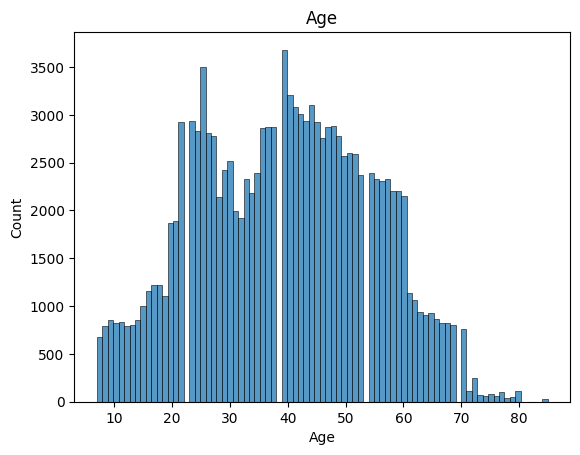

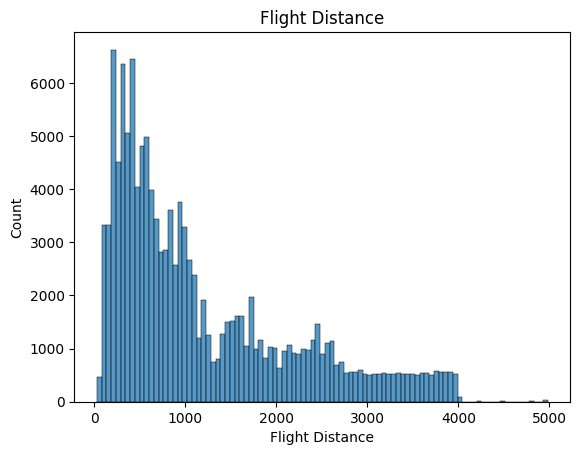

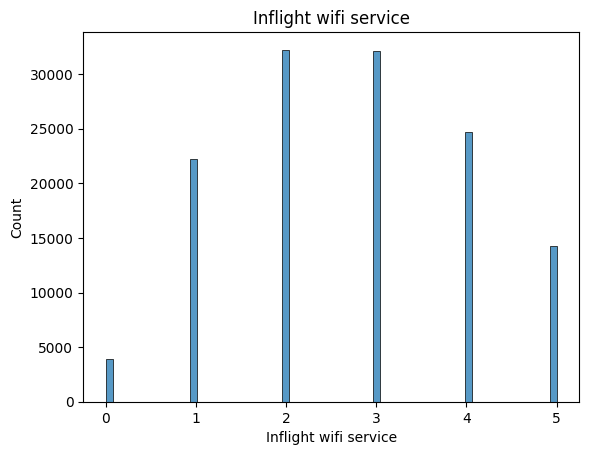

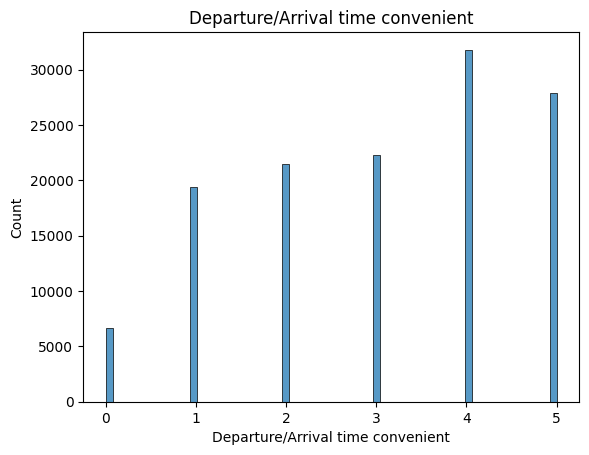

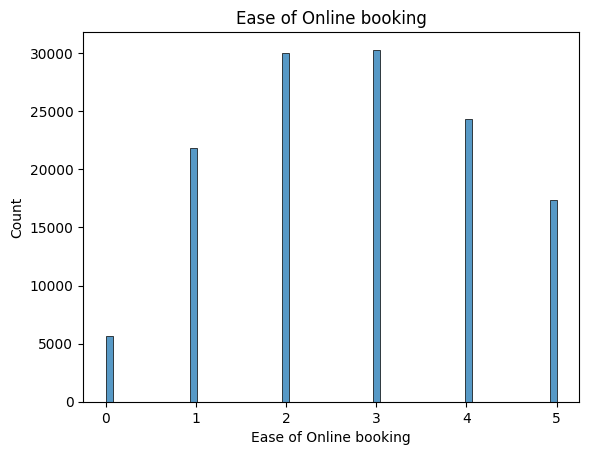

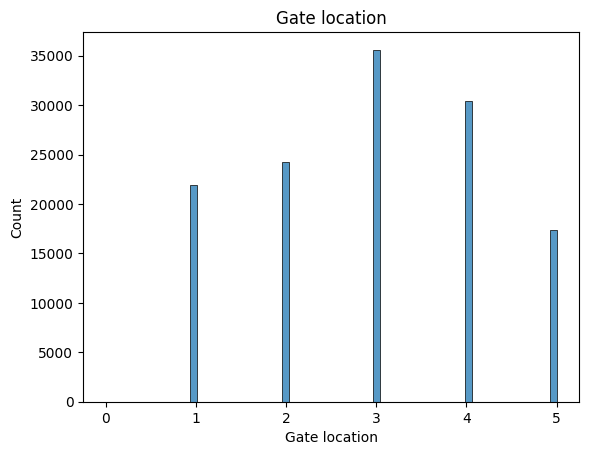

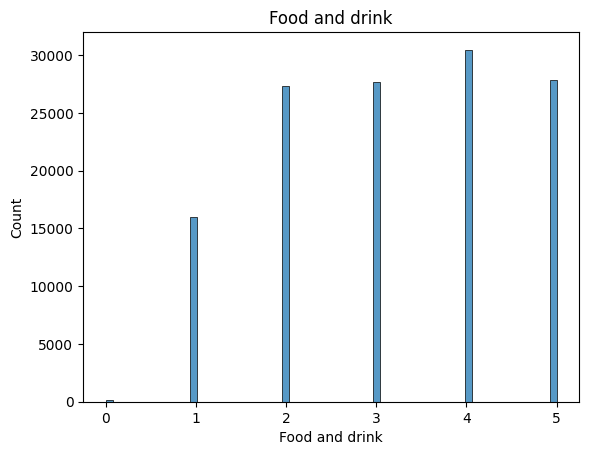

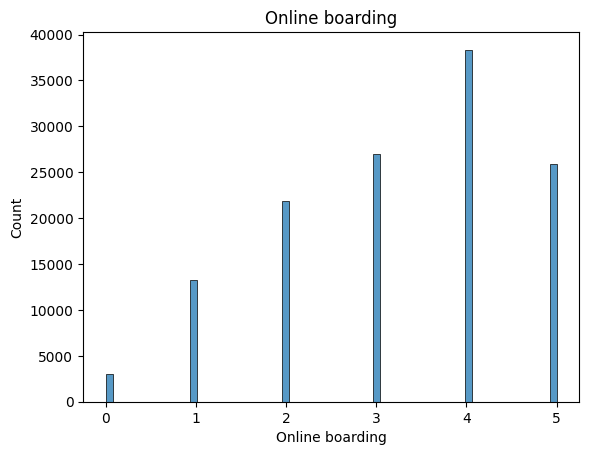

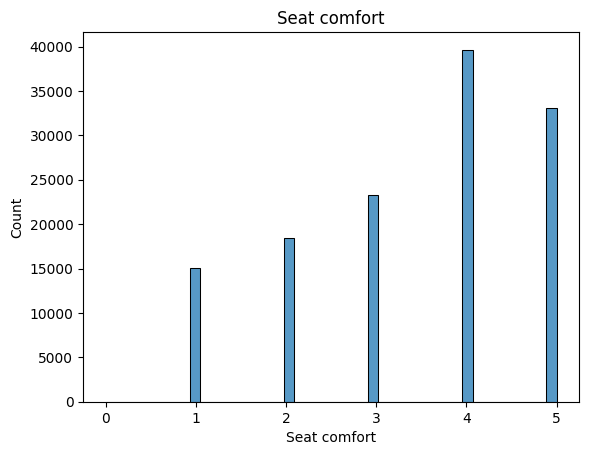

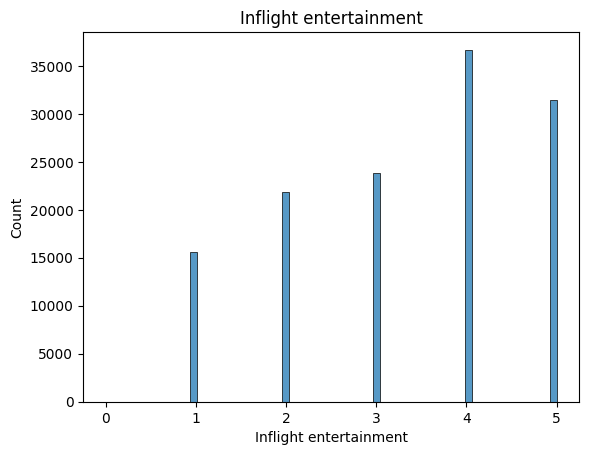

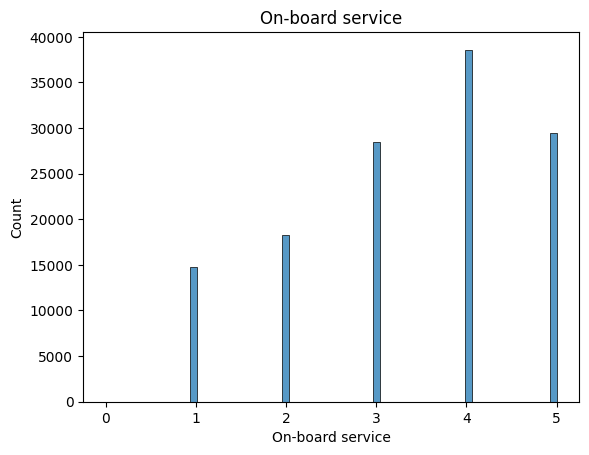

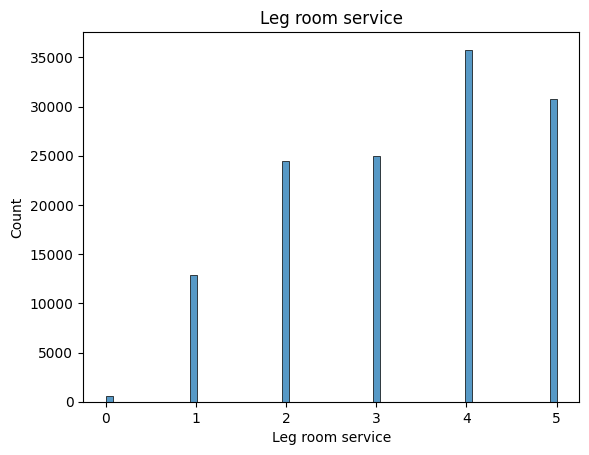

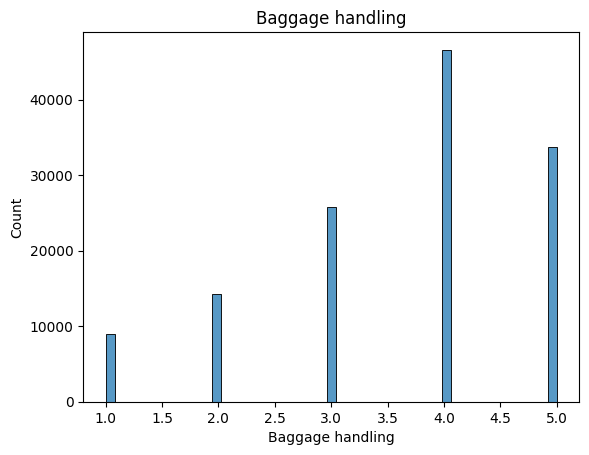

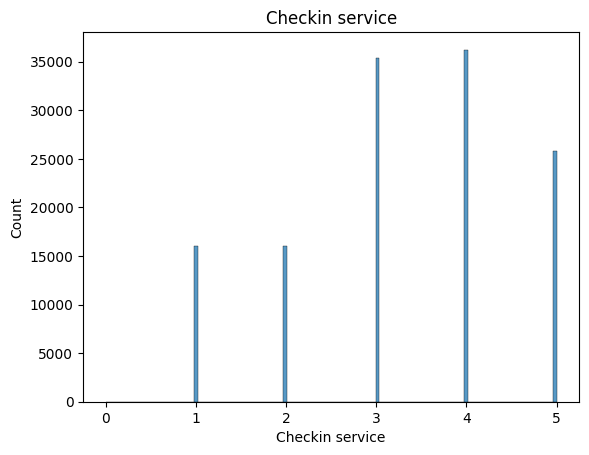

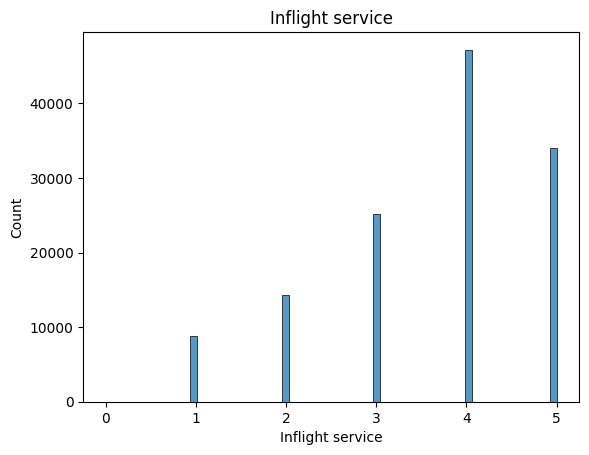

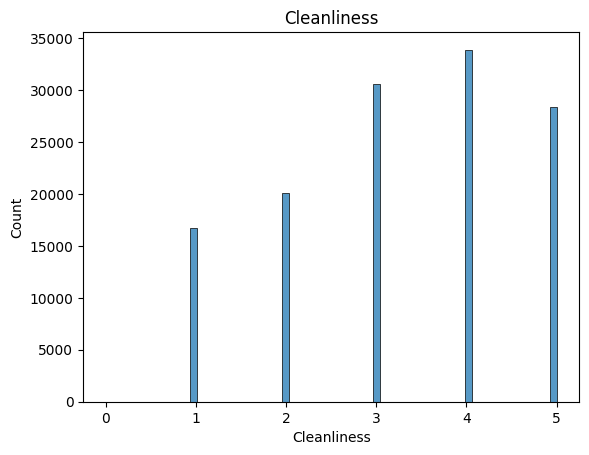

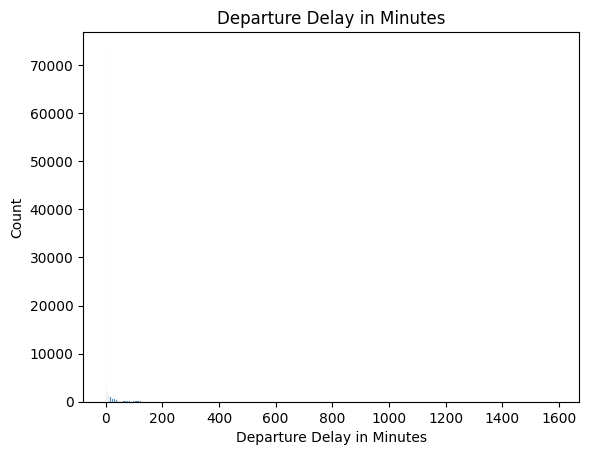

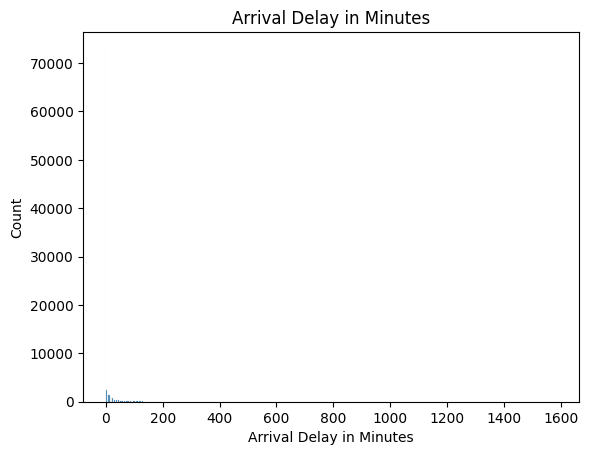

In [11]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    sns.histplot(df[col])
    plt.title(col)
    plt.show()

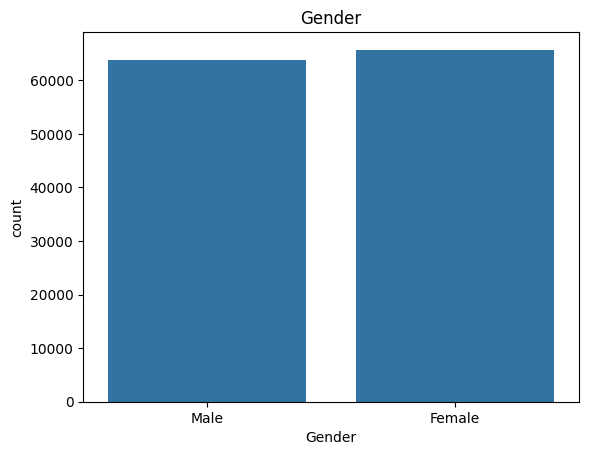

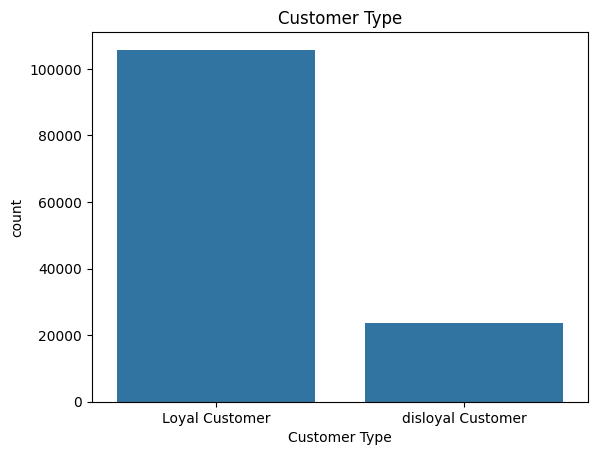

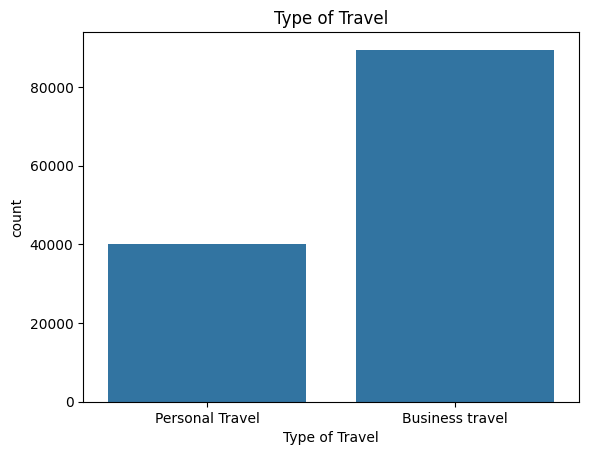

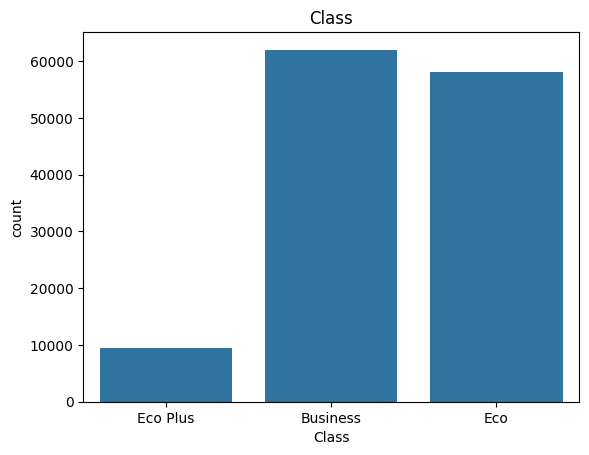

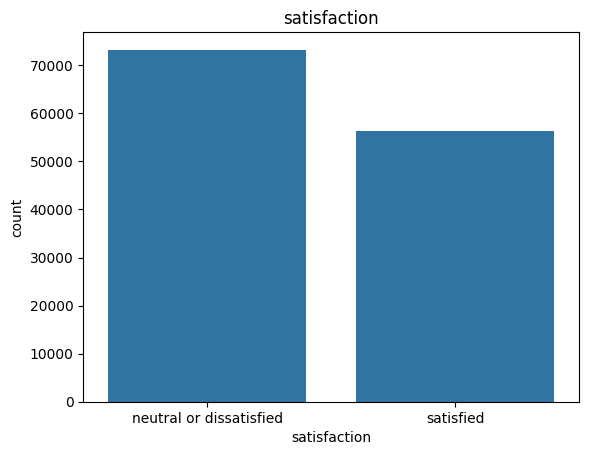

In [12]:
obj_cols = df.select_dtypes(include=['object']).columns

for col in obj_cols:
    sns.countplot(x=col, data=df)
    plt.title(col)
    plt.show()


#### Observations

The histograms and the .describe() table together show that the dataset’s numeric features fall into a few clear distributional patterns that matter for modelling satisfaction. Demographic variables like Age are roughly symmetric yet bimodal, centred around 26 and 40, suggesting a broad but stable passenger population without extreme outliers. This could be relate to there being two distinct groups of travelers, young adults and mid-career professionals, which would likely interact with travel type (correlation heatmap below). Flight Distance, by contrast, is heavily right‑skewed: most flights are short or medium haul, but a small number extend to nearly 5,000 miles. This long‑tailed behaviour hints that distance may interact with satisfaction differently for short versus long flights and may require scaling or transformation for certain models.

Most service rating features (wifi, booking, comfort, entertainment, cleanliness, etc.) share a consistent structure: values range from 0 to 5, with means clustered between 2.7 and 3.6 and relatively tight standard deviations. Their histograms show a concentration around mid‑range ratings with tapering toward the extremes. The presence of zeros across many service categories is notable. They may represent “not applicable” responses rather than genuine dissatisfaction, which could influence how these variables are interpreted or preprocessed. The similarity across these distributions suggests that satisfaction is shaped by a bundle of correlated service experiences rather than any single factor.

Operational performance variables, Departure Delay and Arrival Delay, stand out as the most skewed features. Although the mean delay is around 14–15 minutes, the median is 0 and the maximum exceeds 1,500 minutes. The histograms show a spike at zero followed by a long right tail, indicating that most flights run on time but a small number experience extreme disruptions. These rare but severe delays are likely to be strong predictors of dissatisfaction and may benefit from transformation in linear models.

Taken together, these distributional patterns provide a clear picture of how the dataset behaves: stable demographic features, mid‑centred service ratings, and highly skewed operational metrics. This informs both preprocessing decisions, such as scaling, handling zeros, and managing skew, and expectations about which features are likely to drive predictive performance.

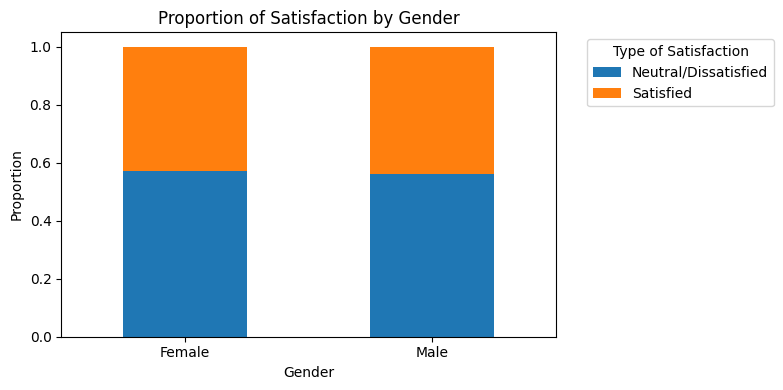

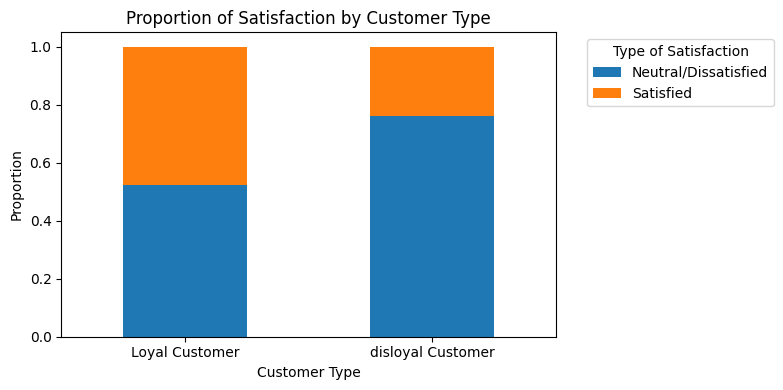

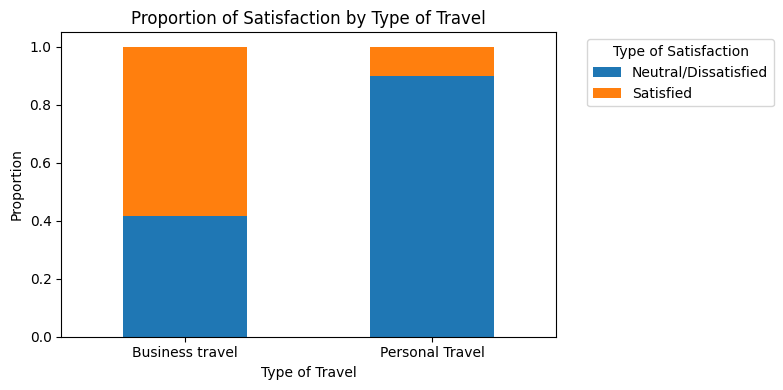

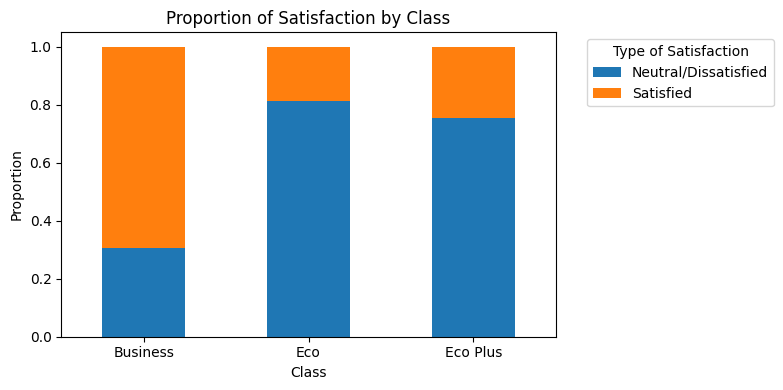

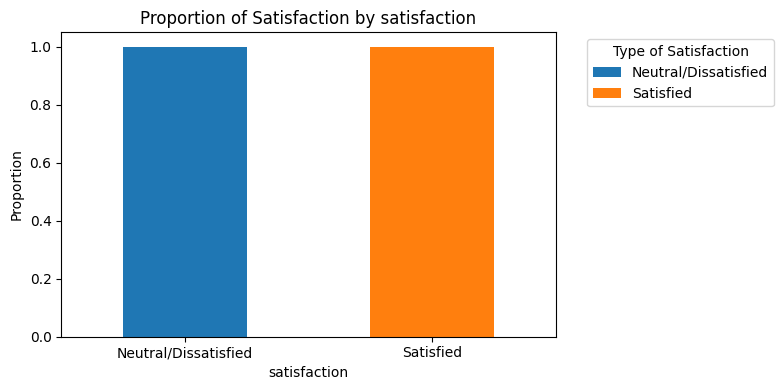

In [13]:
# Remapping 'satisfaction' numeric labels to words for visualization purposes
df['satisfaction'] = df['satisfaction'].map({'neutral or dissatisfied': 'Neutral/Dissatisfied', 'satisfied': 'Satisfied'})

#Creating a for-loop to present all dtype = objects features in proportion plots against type of satisfaction
for col in obj_cols:
    prop = pd.crosstab(df[col], df['satisfaction'], normalize='index')
    ax = prop.plot(kind='bar', stacked=True, figsize=(8, 4)) #, colormap='tab20')
    ax.set_ylabel('Proportion')
    ax.set_title(f'Proportion of Satisfaction by {col}')
    ax.legend(title='Type of Satisfaction', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()


##### Observations

The proportion plots reveal clear structural patterns in how satisfaction varies across key categorical features, particularly Class and Type of Travel. These patterns show that satisfaction is not evenly distributed across the passenger population but instead clusters around groups with different expectations, service levels, and travel contexts.

Class shows the strongest stratification. Business Class passengers are disproportionately represented among satisfied customers, while Economy and Economy Plus passengers account for most of the dissatisfied group. This aligns with the intuitive expectation that Business Class offers enhanced comfort, amenities, and service consistency, all of which contribute to higher satisfaction. Even without explicit information on loyalty tiers or fare types, the class-based differences suggest that the quality of the inflight experience is a major determinant of satisfaction.

A similar pattern emerges in Type of Travel. Business travellers report higher satisfaction rates than personal or leisure travellers. This may reflect differences in expectations and priorities: business travellers often value punctuality, efficiency, and service reliability, and may also receive additional benefits through corporate travel programmes. Personal travellers, by contrast, may be more sensitive to cost, comfort, or disruptions, leading to more varied satisfaction outcomes.

Together, these proportion plots highlight that satisfaction is shaped by structural travel choices—the class of service purchased and the purpose of travel. These features are therefore highly predictive and likely to interact with service‑quality ratings in the modelling process. They also reinforce the idea that satisfaction is not driven by isolated experiences but by broader contextual factors that shape how passengers interpret and evaluate their journey.


*Side note: Due to how I encoded in previous steps, the final graph here is satisfaction against satisfaction. I am aware it is not necessary/useful. given that it is being evaluated against itself, but I did not want to re-encode the for loop/object repetitively. Please forgive me :)*

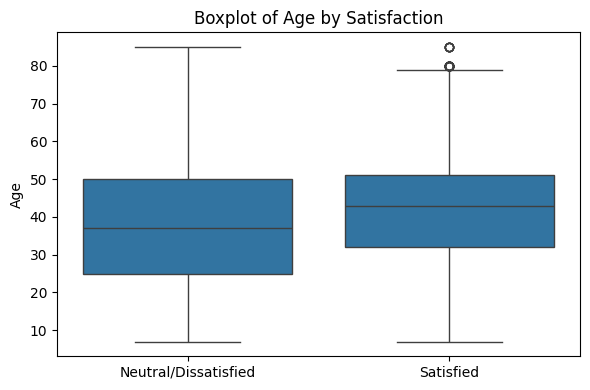

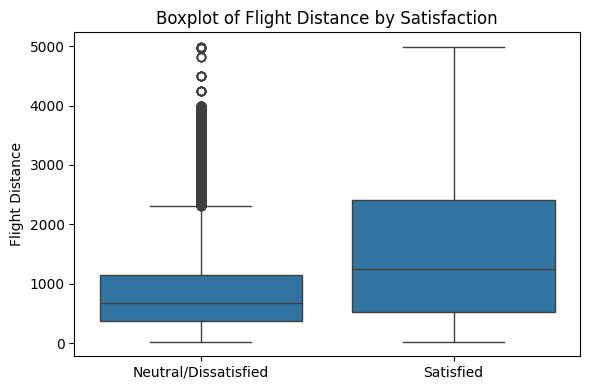

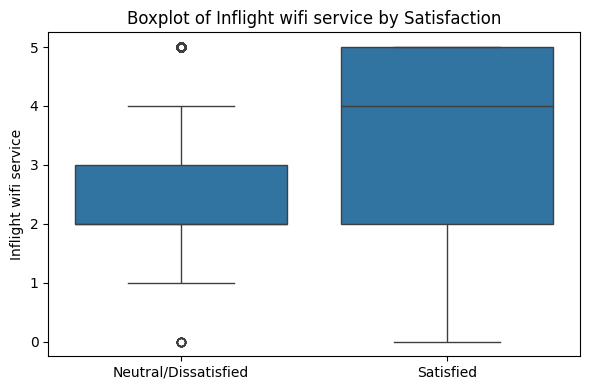

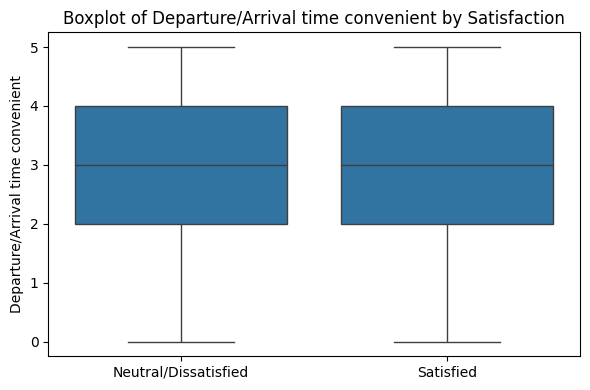

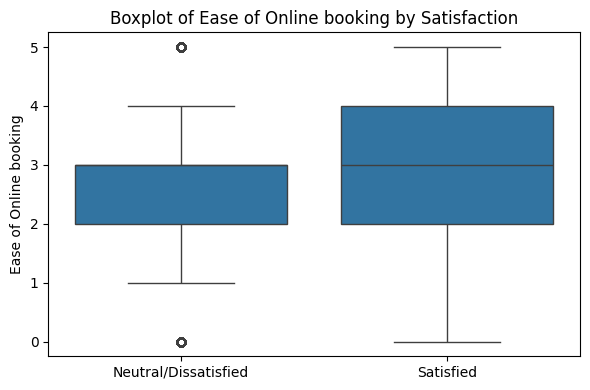

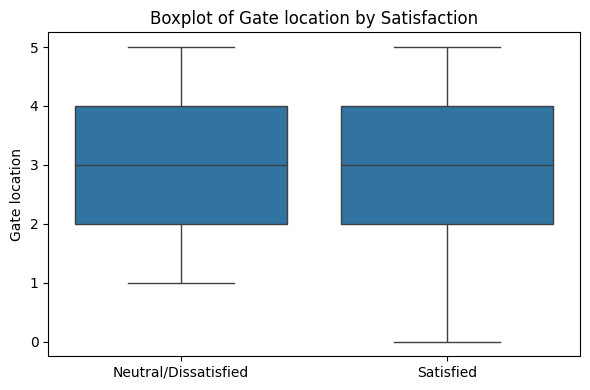

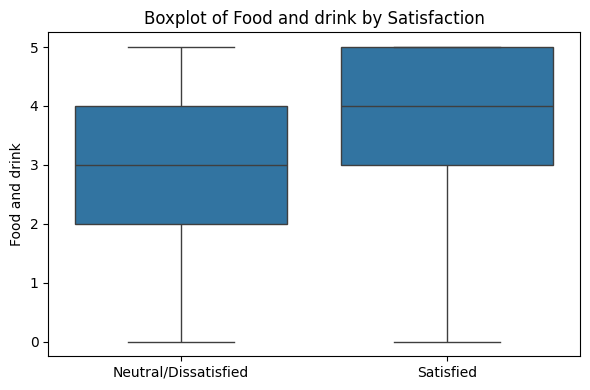

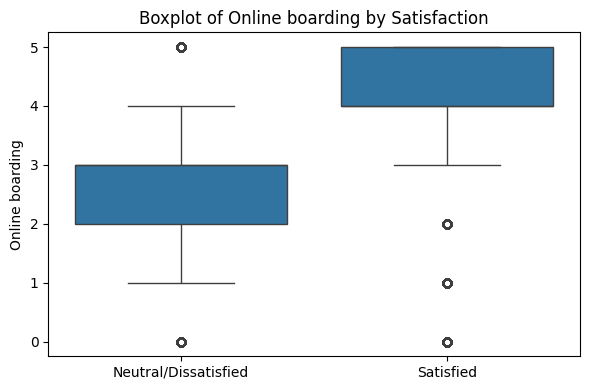

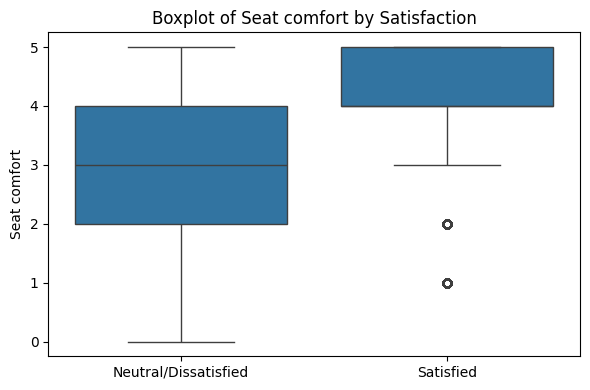

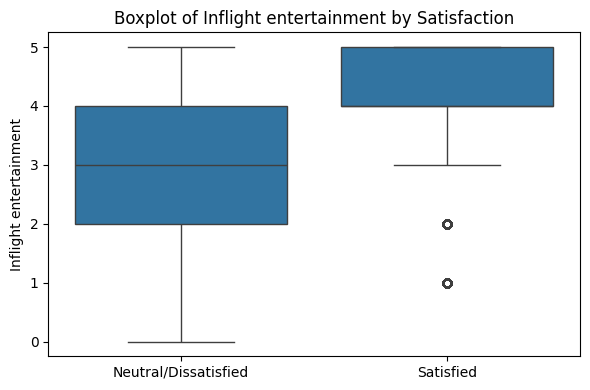

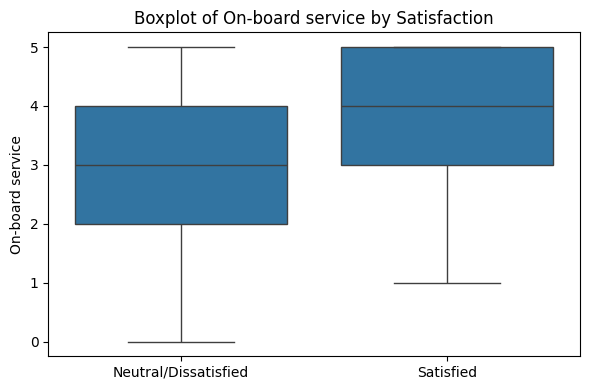

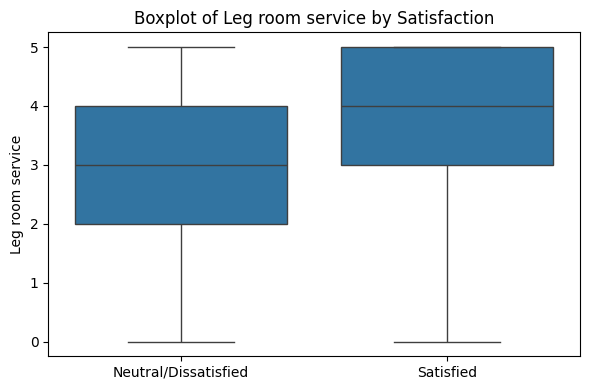

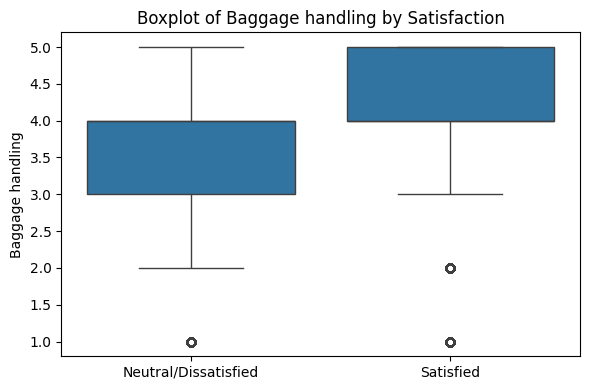

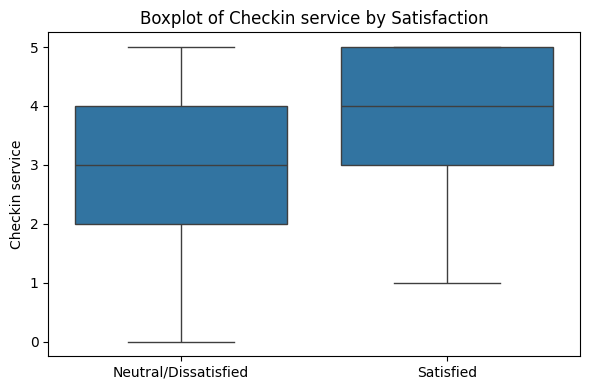

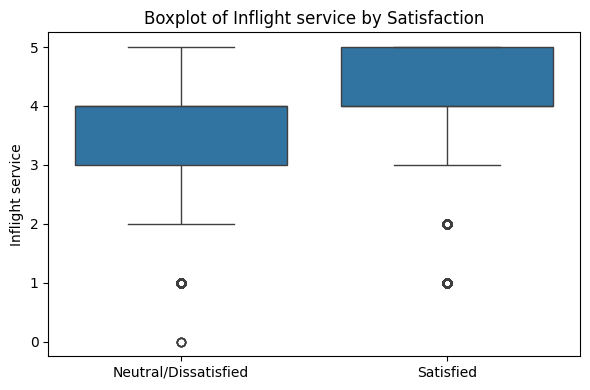

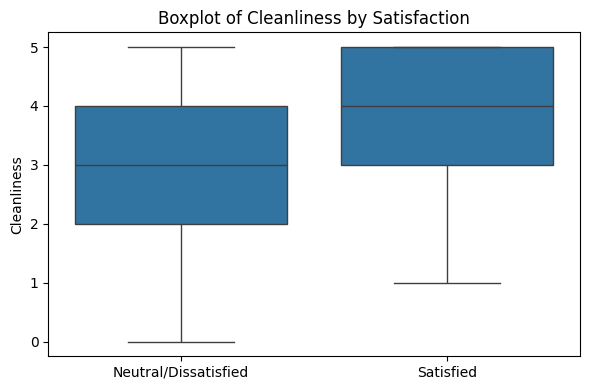

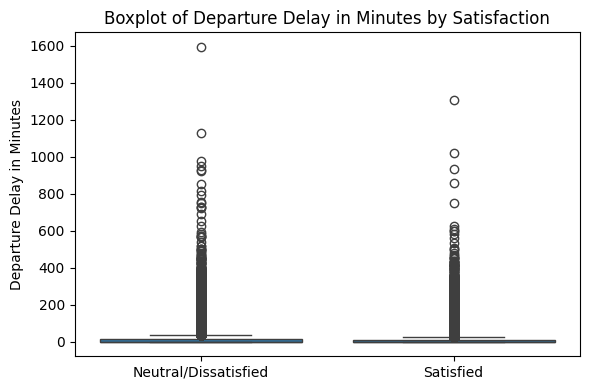

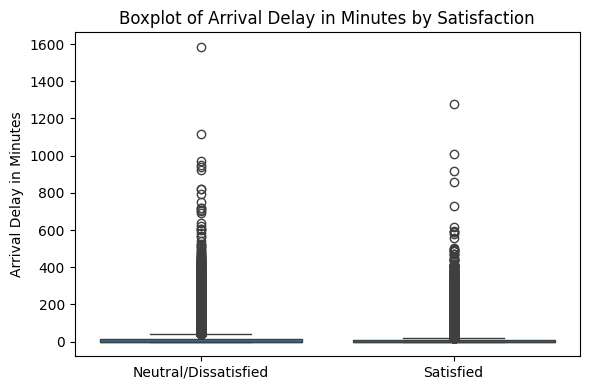

In [14]:
#Reapting that step / for-loop to present all dtype = int/float features in proportion plots against type of satisfaction

for col in num_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x='satisfaction', y=col, data=df)
    plt.title(f'Boxplot of {col} by Satisfaction')
    plt.xlabel("")
    plt.tight_layout()
    plt.show()


##### Observations

The full set of boxplots provides a comprehensive view of how each numeric feature differs between satisfied and dissatisfied passengers, revealing clear patterns about which aspects of the travel experience matter most. Across nearly all service‑quality variables, satisfied passengers consistently give higher ratings, while dissatisfied passengers show wider spreads and more low values. This pattern reinforces the central role of service quality in shaping satisfaction.

Several features show particularly strong separation. Online boarding, inflight Wi‑Fi service, seat comfort, inflight entertainment, on‑board service, and cleanliness all display higher medians and tighter distributions for satisfied passengers. These variables represent core components of the digital and inflight experience, and their boxplots align closely with the Random Forest feature importance rankings. Passengers who report positive experiences in these areas are far more likely to be satisfied overall, indicating that comfort, convenience, and service consistency are foundational to the passenger journey.

Other service features—such as food and drink, leg room service, check‑in service, and baggage handling—show moderate but meaningful differences between groups. Satisfied passengers tend to rate these features higher, though the overlap between distributions suggests that they contribute to satisfaction but are not decisive on their own. These variables likely interact with more influential features, amplifying or dampening the overall experience depending on the context.

Operational metrics such as departure delay and arrival delay show only subtle differences. Dissatisfied passengers experience slightly higher delays on average, but the distributions overlap heavily, reflecting the fact that most flights in the dataset depart and arrive on time. Delays appear to influence satisfaction primarily when they are severe, consistent with the long‑tailed distributions observed earlier.

Demographic variables such as age show almost no separation between groups, indicating that satisfaction is not meaningfully shaped by passenger age alone. Similarly, flight distance shows only a modest difference, with satisfied passengers travelling slightly farther on average. This suggests that distance may influence satisfaction indirectly, perhaps through better amenities or higher likelihood of premium cabins on long‑haul routes, but is not a standalone driver.

Taken together, the boxplots show that satisfaction is driven primarily by digital experience, comfort, and service quality, with operational and demographic factors playing a secondary or contextual role. The consistent separation across multiple service‑related features highlights that satisfaction is not determined by a single touchpoint but by the cumulative effect of many aspects of the journey. These insights reinforce the need for models capable of capturing complex, non‑linear interactions—such as Decision Trees and Random Forests—and provide a clear empirical foundation for understanding what matters most to passengers.

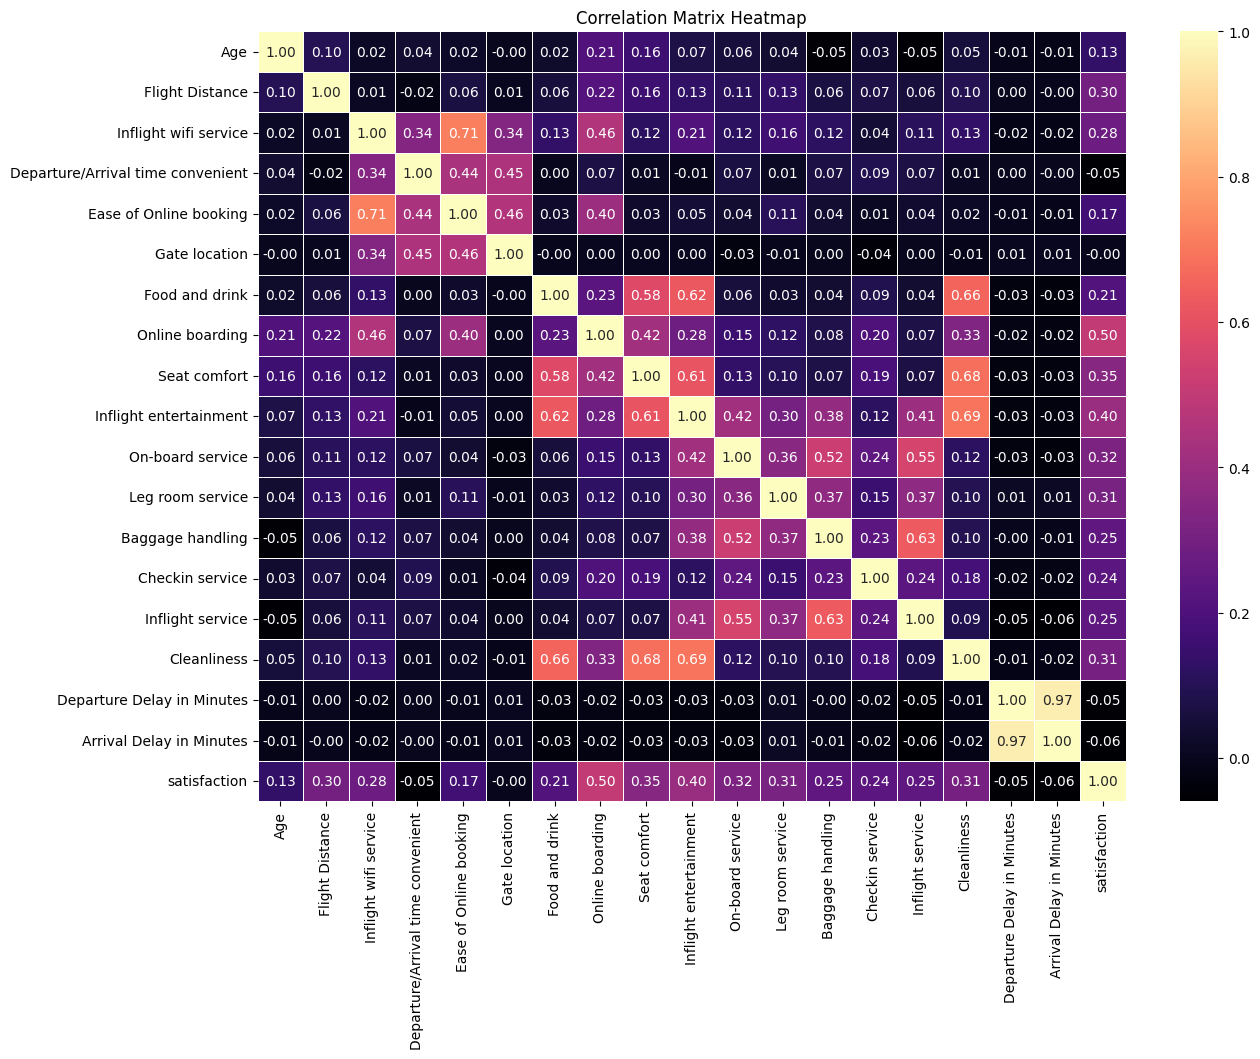

In [15]:
#Quick recoding for matrix building
df['satisfaction'] = df['satisfaction'].map({'Satisfied': 1, 'Neutral/Dissatisfied': 0})

#Build correlation matrix
corr_matrix = df[num_cols.tolist() + ['satisfaction']].corr()

#Plot heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='magma',
    fmt=".2f",
    linewidths=0.5)

plt.title("Correlation Matrix Heatmap")
plt.show()

#### Observations

The correlation heatmap highlights a few clear structural patterns in how the numeric features relate to one another and to satisfaction and explain which constituent parts of the passenger experience tend to move together. The strongest correlations appear within the cluster of service‑rating variables—features like seat comfort, inflight entertainment, cleanliness, and onboard service all show moderate to strong positive relationships with each other. This indicates that passengers who rate one aspect of the service higher tend to rate others higher as well, suggesting a shared underlying dimension of overall service quality. These same features also show the clearest positive correlations with satisfaction, reinforcing that the customer experience during the flight is one of the most influential drivers of whether a passenger leaves satisfied.

Operational variables such as departure and arrival delays form a different pattern. They correlate strongly with each other, as expected, but show only weak negative correlations with satisfaction. This suggests that while delays do matter, they are not as consistently tied to satisfaction as service quality is—likely because many passengers experience small delays without perceiving them as major disruptions. Flight distance shows only minimal correlation with satisfaction and weak relationships with most other features, indicating that distance alone does not meaningfully shape the passenger experience once other factors are accounted for.

Taken together, the heatmap shows that satisfaction is most closely tied to a coherent block of service‑related features, while operational metrics and demographic variables play a more limited role. This structure suggests that models predicting satisfaction will likely draw most of their signal from the service‑quality cluster, and that these variables may exhibit multicollinearity that tree‑based models can handle more naturally than linear ones.

# Model Selection & Evaluation

### Data Splitting

In [16]:
#Creating new dataframes for each train/test/target classification

X = df.drop('satisfaction', axis=1) 
y = df['satisfaction'] # recoded earlier in workflow, so there is no need to recode into binary now

### Train-test split

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(103589, 22)
(25898, 22)
(103589,)
(25898,)


#### Observations

Before training predictive models, the dataset was split into training and testing subsets, an 80/20 split, respectively. This step is important to ensure that model performance is evaluated on data that was not used during training. By separating the dataset in this wBefore training predictive models, the dataset was split into training and testing subsets. This step is important to ensure that model performance is evaluated on data that was not used during training. By separating the dataset in this way, we obtain a more reliable estimate of how well the model will generalise to new passenger data.


### One-hot encoding AFTER splitting

In [18]:
X_train = pd.get_dummies(X_train, drop_first=False).astype(int)
X_test = pd.get_dummies(X_test, drop_first=False).astype(int)

#X_train.head(5)
X_test.head(5)

,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,...,Arrival Delay in Minutes,Gender_Female,Gender_Male,Customer Type_Loyal Customer,Customer Type_disloyal Customer,Type of Travel_Business travel,Type of Travel_Personal Travel,Class_Business,Class_Eco,Class_Eco Plus
98173,51,1587,1,4,1,1,4,4,5,4,...,0,1,0,1,0,1,0,1,0,0
24942,38,936,3,3,3,3,3,3,3,3,...,0,0,1,0,1,1,0,1,0,0
69235,7,669,3,4,2,3,5,2,5,5,...,0,1,0,1,0,0,1,0,1,0
90480,42,1832,1,1,1,1,5,4,4,4,...,0,0,1,1,0,1,0,1,0,0
36184,52,2143,3,2,2,2,1,2,2,3,...,0,0,1,1,0,1,0,1,0,0


#### Observations

Categorical variables such as gender, customer type, type of travel, and travel class were converted into numerical format using one-hot encoding. Machine learning algorithms generally require numerical inputs, and one-hot encoding allows categorical information to be represented without introducing an artificial ordinal relationship between categories. 
This approach ensures that each category is treated independently by the model. For example, the travel class variable contains three distinct categories (Business, Economy, and Economy Plus), which represent different service levels but do not follow a strictly numerical progression. One-hot encoding allows the model to learn separate relationships between each class and passenger satisfactio 

Retaining these categorical features is important because earlier exploratory analysis suggested that travel class and travel purpose are strongly associated with satisfaction outcomes. Encoding these variables therefore allows the models to capture these structural differences within the passenger populatio



As the dataset contained several categorical features, I considered between using pd.get.dummies or line-by-line reclassification for the binary features (Gender, Customer Type, Type of Travel) with one-hot encoding for the multi-class 'Class' feature (as it held three categories within the feature). I coded both (as seen below) but ultimately went with the pd.get.dummies version as it was smplier by allowing me to re-encode all categorical variables at once through one line command, preventing the risk of inconsistencies across dataframes (and if/when new data get introduced). One major consideration here was deciding if I want to fully drop instances (= True) and/or creating new, potentiaunnecessarysary features (= False). Considering the ease of readiability down the road with model development, cidedcded to fully split the encoded features as seen above.

##### Binary reclassification, another method

#X['Gender'] = X['Gender'].map({'Male': 1, 'Female': 0})

#X['Customer Type'] = X['Customer Type'].map({'Loyal Customer': 1, 'disloyal Customer': 0})

#X['Type of Travel'] = X['Type of Travel'].map({'Personal Travel': 1, 'Business travel': 0})

##### One-Hot Encoding for 'Class'

#Create the encoder
encoder = OneHotEncoder(sparse_output=False)

#Fit + transform the 'Class' column
one_hot_encoded = encoder.fit_transform(X[['Class']])

#Create a DataFrame with the encoded columns
one_hot_df = pd.DataFrame(
    one_hot_encoded,
    columns=encoder.get_feature_names_out(['Class'])
)

#Combine with original df (dropping the original column)
X = pd.concat([X.drop(columns=['Class']), one_hot_df], axis=1)

X.head()


### Baseline Models

The earlier exploratory analysis suggested that satisfaction is influenced by a combination of service quality ratings, travel characteristics, and operational factors such as delays. These relationships may not be purely linear, particularly because interactions between variables (for example, travel class and service ratings) may influence satisfaction outcomes. For this reason, multiple models with different learning approaches were explored, including a linear model (Logistic Regression) and tree-based models (Decision Tree and Random Forest). Comparing these models allows us to evaluate whether more flexible algorithms provide improved predictive performance.ay, we obtain a more reliable estimate of how well the model will generalise to new passenger data.e.

In [19]:
#Logisitic Regression

log_reg = LogisticRegression(
    max_iter=5000,
    penalty = 'l2', #included these based on readings / exploring program documentation to better design the model based on the high-dimensional,sparse dataset after one-hot encoding
    solver='saga', #included these based on readings / exploring program documentation to better design the model based on the high-dimensional,sparse dataset after one-hot encoding
    random_state=42,
    n_jobs=-1
)

log_reg.fit(X_train, y_train)

LogisticRegression(max_iter=5000, n_jobs=-1, random_state=42, solver='saga')

In [20]:
#Decision Tree

dt = DecisionTreeClassifier(
    criterion='gini',
    max_depth=None,
    min_samples_split=2,
    random_state=42
)

dt.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [21]:
#Random Forest, Part 1

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)


RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=42)

#### Observations
To establish initial performance benchmarks, I trained three baseline models: Logistic Regression, Decision Tree, and Random Forest. These models were selected to represent increasing levels of modelling flexibility, from a linear decision boundary, to a single non‑linear tree, to a full ensemble capable of capturing complex interactions. Together, they provide a structured foundation for understanding how different modelling assumptions perform on the same preprocessed dataset.

Logistic Regression served as the linear baseline and was particularly useful for understanding broad directional relationships in the data. After one‑hot encoding, the dataset becomes high‑dimensional and sparse, with many correlated categorical indicators. This structure informed two key design decisions (based on further exploration through readings and searching the the documentation). First, I applied L2 regularisation, which shrinks coefficients smoothly toward zero without eliminating features entirely. From what I read, it is well‑suited to high‑dimensional categorical expansions where many predictors contribute small but meaningful signals, and it helps mitigate overfitting in the presence of multicollinearity. Second, I selected the ‘saga’ solver, which is specifically optimised for large, sparse datasets and supports L2 regularisation efficiently. Because Logistic Regression is sensitive to feature scaling and the optimisation landscape becomes more complex with high‑dimensional data, I increased the maximum iteration limit to ensure convergence. The model continued to raise convergence warnings at 2,000 iterations, so I increased the limit to 5,000. While this improved stability, it also increased computational cost, highlighting the trade‑off between runtime and optimisation reliability (even on my GPU-enabled laptop). Overall, Logistic Regression provided a transparent baseline but was ultimately constrained by its linear decision boundary, which inhibited its ability to capture interactions among service ratings, travel characteristics, and demographic features.

The Decision Tree model introduced non‑linearity and the ability to learn conditional relationships directly from the data. Trees naturally capture interactions—such as how dissatisfaction may arise only when certain service ratings fall below a threshold and the passenger is travelling in a particular class. However, because the tree was allowed to grow without depth restrictions, it was prone to overfitting, learning highly specific patterns that do not generalize as well as an ensemble model. While the Decision Tree improved interpretability of non‑linear splits and provided insight into feature interactions, its standalone predictive performance was weaker than the Random Forest.

Random Forest was selected as a stronger non‑linear baseline capable of capturing feature interactions and complex modelling patterns without requiring feature scaling (re: log transformation discussed earlier). The ensemble structure, aggregating predictions from many decorrelated decision trees, allowed me to capture heterogeneous patterns in customer behaviour, including threshold effects and non‑linear dependencies. I selected a 300-tree configuration at start as a balance between predictive model stability and training/computational efficiency. At this level, the model benefits from variance reduction while remaining computationally manageable.

Together, these three models illustrate how predictive performance improves as modelling flexibility increases. Logistic Regression establishes a clear interpretability‑focused linear baseline; the Decision Tree demonstrates the value of non‑linear splits but suffers from overfitting; and the Random Forest shows the performance gains achievable when modelling interactions and non‑linear relationships through an ensemble. Based on these characteristics and the evaluation results that follow, I continued model development using Random Forest, as it is better suited to high‑dimensional categorical data, more robust to noise, and provides feature importance measures that support interpretability and downstream business insights.

In [22]:
#Model Evaluation

def evaluate(model, name):
    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:, 1]

    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_test, preds))
    print("Precision:", precision_score(y_test, preds))
    print("Recall:", recall_score(y_test, preds))
    print("F1:", f1_score(y_test, preds))
    print("ROC-AUC:", roc_auc_score(y_test, probs))
    print("\nConfusion Matrix:\n", confusion_matrix(y_test, preds))
    print("\nClassification Report:\n", classification_report(y_test, preds))

evaluate(log_reg, "Logistic Regression")
evaluate(dt, "Decision Tree")
evaluate(rf, "Random Forest")



Logistic Regression
Accuracy: 0.855162560815507
Precision: 0.830490499337163
Recall: 0.8367764915405165
F1: 0.8336216455976934
ROC-AUC: 0.912822340768341

Confusion Matrix:
 [[12750  1918]
 [ 1833  9397]]

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.87      0.87     14668
           1       0.83      0.84      0.83     11230

    accuracy                           0.86     25898
   macro avg       0.85      0.85      0.85     25898
weighted avg       0.86      0.86      0.86     25898


Decision Tree
Accuracy: 0.946559579890339
Precision: 0.935124624359201
Recall: 0.9421193232413179
F1: 0.9386089425124201
ROC-AUC: 0.9460392089345395

Confusion Matrix:
 [[13934   734]
 [  650 10580]]

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.95      0.95     14668
           1       0.94      0.94      0.94     11230

    accuracy                           0.95     2589

#### Observations

When comparing model performance, it is important to consider not only overall accuracy but also the balance between precision and recall. In the context of predicting passenger satisfaction, both metrics are important because the goal is to correctly identify both satisfied and dissatisfied passengers.

##### Logistic Regression performance
Logistic Regression achieved an accuracy of 0.86, with precision (0.83), recall (0.84), and F1 (0.83), indicating balanced performance across classes. The ROC–AUC of 0.91 shows that the model separates satisfied and dissatisfied customers reasonably well, even though its decision boundary is linear. The confusion matrix highlights the model’s main limitation: it misclassifies a substantial number of dissatisfied customers as satisfied (1,918 false positives). This pattern is typical of linear models applied to datasets where relationships are driven by complex, non‑linear interactions—such as combinations of service ratings, delays, and travel class. These effects are often conditional or threshold‑based, meaning they cannot be captured effectively by a single linear boundary. While Logistic Regression provides a strong and interpretable baseline, these structural limitations restrict its ability to model the richer interactions present in the data. Nonetheless, it establishes a clear performance floor and offers interpretable coefficients that help identify broad directional relationships between features and customer satisfaction.

##### Decision Tree performance
The Decision Tree classifier improved substantially on the Logistic Regression baseline, achieving 0.95 accuracy, 0.94–0.96 precision and recall, and a ROC–AUC of 0.95. These results reflect the model’s ability to learn non‑linear decision rules and capture interactions directly from the data. The confusion matrix shows far fewer false positives (734) and false negatives (650) compared to Logistic Regression, indicating that the tree is better at identifying both satisfied and dissatisfied customers. However, the model’s strong performance comes with an important caveat: because the tree was allowed to grow without depth restrictions, it is likely overfitting to the training data. While hyperparameters could be set to limit this, Decision Trees are known to produce highly specific splits that capture noise rather than general patterns, especially in large, high‑dimensional datasets. While the Decision Tree provides valuable insight into feature interactions and conditional relationships, its standalone generalisation performance remains weaker than the Random Forest, which mitigates overfitting through ensembling.

##### Random Forest performance
Random Forest substantially outperformed Logistic Regression across all evaluation metrics. It achieved 0.96 accuracy, 0.97 precision, 0.94 recall, and an F1 score of 0.96, demonstrating strong and well‑balanced predictive performance. The ROC–AUC of 0.99 indicates near‑perfect class separation, suggesting that the model captures the underlying structure of the data extremely effectively. The confusion matrix shows very low false positives (309) and relatively low false negatives (656), indicating that the model reliably identifies both satisfied and dissatisfied customers. This improvement reflects Random Forest’s ability to model non‑linear relationships and feature interactions that Logistic Regression cannot capture. For example, dissatisfaction may arise only when certain service ratings fall below a threshold and the passenger experienced a delay—patterns that tree‑based models naturally detect. The strength of the Random Forest results suggests that customer satisfaction is driven by complex, interacting factors rather than simple linear relationships. As such, Random Forest provides a more realistic representation of the decision boundaries inherent in the dataset and forms a strong foundation for further model development and interpretation.

## Model Comparison Discussion

The project evaluated three machine learning models, Logistic Regression, Decision Tree, and Random Forest, to determine which approach most effectively predicts airline passenger satisfaction. These models represent increasing levels of modelling flexibility, allowing a structured comparison between linear, single‑tree, and ensemble‑based methods.

Logistic Regression served as the linear baseline due to its simplicity and interpretability. It achieved balanced performance, with an accuracy of 0.86 and a ROC–AUC of 0.91, demonstrating that it captures broad directional trends in the data. However, the model struggled with the substantial non‑linear structure of the dataset, misclassifying many dissatisfied customers as satisfied. This limitation reflects the nature of the problem: passenger satisfaction is shaped by interacting service‑quality variables—such as comfort, digital experience, and operational reliability—that cannot be represented effectively by a single linear decision boundary.

The Decision Tree classifier improved considerably on the Logistic Regression baseline, achieving 0.95 accuracy and a ROC–AUC of 0.95. Its ability to learn non‑linear splits and conditional relationships allowed it to capture more of the underlying structure of the data. The tree correctly identified far more dissatisfied customers than Logistic Regression, demonstrating the value of modelling interactions directly. However, because the tree was allowed to grow without depth restrictions, it was prone to overfitting—learning highly specific patterns that do not generalise as well as an ensemble. While the Decision Tree provided valuable insight into feature interactions, its standalone performance remained less stable than the Random Forest.

The Random Forest classifier delivered the strongest and most reliable performance across all metrics. With an accuracy of 0.96, precision of 0.97, recall of 0.94, and a ROC–AUC of 0.99, it demonstrated excellent generalisation and near‑perfect class separation. By aggregating predictions from many decorrelated trees, the Random Forest mitigates overfitting while capturing complex, high‑order interactions that neither Logistic Regression nor a single Decision Tree can model effectively. Its low false‑positive and false‑negative rates further highlight its robustness and suitability for this prediction task.

Overall, the comparison shows a clear progression: Logistic Regression provides a useful interpretability baseline, the Decision Tree introduces non‑linearity and interaction modelling, and the Random Forest combines these strengths while reducing their weaknesses. The results reinforce that passenger satisfaction is driven by multiple interacting factors rather than any single dominant feature. Models capable of capturing these interactions—particularly ensemble methods like Random Forest—deliver the most accurate, stable, and generalisable performance.

In [23]:
# Feature Importance (sorted descending)

importances = rf.feature_importances_
feature_names = X_train.columns  # ensures alignment with model input

sorted_idx = np.argsort(importances)[::-1]  # descending order

for i in sorted_idx[:20]:
    print(f"{feature_names[i]}: {importances[i]:.4f}")


Online boarding: 0.1633
Inflight wifi service: 0.1380
Class_Business: 0.0722
Type of Travel_Personal Travel: 0.0641
Inflight entertainment: 0.0615
Type of Travel_Business travel: 0.0532
Seat comfort: 0.0445
Ease of Online booking: 0.0366
Class_Eco: 0.0338
Flight Distance: 0.0300
On-board service: 0.0287
Age: 0.0280
Leg room service: 0.0276
Customer Type_Loyal Customer: 0.0274
Checkin service: 0.0254
Baggage handling: 0.0248
Cleanliness: 0.0245
Customer Type_disloyal Customer: 0.0242
Inflight service: 0.0231
Gate location: 0.0145


#### Observations

The feature importance results point to a clear hierarchy in what drives customer satisfaction. Online boarding and inflight Wi‑Fi service stand out as the strongest predictors, highlighting how much digital touchpoints and connectivity shape the customer experience. Other high‑impact contributors include Class (Business/Eco) and Type of Travel, indicating that satisfaction varies meaningfully across travel contexts and customer expectations. Several service‑quality ratings—such as inflight entertainment, seat comfort, on‑board service, leg room, check‑in service, and baggage handling—also appear prominently, reinforcing the importance of comfort and operational reliability throughout the journey. Demographic and behavioural factors like Customer Type (Loyal/Disloyal) and Age contribute as well, suggesting that prior engagement with the airline and passenger characteristics influence satisfaction patterns. Overall, the ranked feature importance profile aligns with domain intuition and supports the credibility of the model’s learned relationships.

## Parameter Fine Tuning

Best params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 750}
              precision    recall  f1-score   support

           0       0.96      0.98      0.97     14668
           1       0.97      0.94      0.96     11230

    accuracy                           0.96     25898
   macro avg       0.96      0.96      0.96     25898
weighted avg       0.96      0.96      0.96     25898

ROC-AUC: 0.9943994850949761


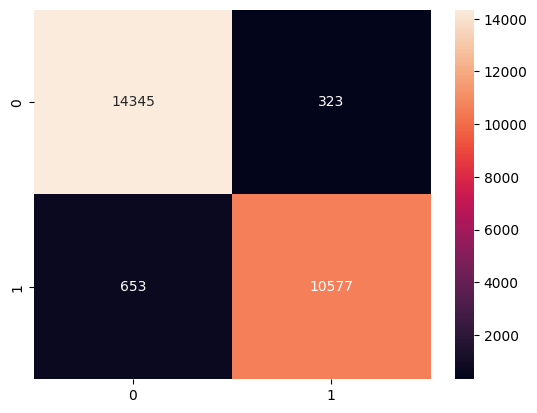

In [24]:
rf = RandomForestClassifier(random_state=42, n_jobs=-1)

param_grid = {
    'n_estimators': [250, 500, 750],
    'max_depth': [None],
    'min_samples_split': [2, 5]
}

grid_rf = GridSearchCV(rf, param_grid, cv=3, scoring='roc_auc', n_jobs=-1)
grid_rf.fit(X_train, y_train)

print("Best params:", grid_rf.best_params_)
best_rf = grid_rf.best_estimator_

y_pred_rf = best_rf.predict(X_test)
y_proba_rf = best_rf.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_rf))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d')
plt.show()


#### Observations

The hyperparameter search explored different combinations of tree count, tree depth, and minimum split size to identify the configuration that maximised ROC–AUC. 

I began the process began with a narrower range of n_estimators (100–200), which initially suggested that performance improved as the ensemble grew. Expanding this range confirmed the trend: larger forests consistently produced more stable and accurate predictions. The full grid search ultimately selected 750 trees, indicating that the model benefits from a large ensemble that reduces variance and captures a wider range of decision patterns.

A similar pattern emerged for max_depth. Although I tested shallower depths (e.g., 10 or 20), the model consistently performed best with no depth restriction, allowing trees to grow fully and capture complex, high‑order interactions in the data. This is consistent with Random Forest’s design philosophy: deep trees combined with bootstrap sampling and feature subsampling tend to generalise well, even when individual trees overfit.

For min_samples_split, the grid search identified 2 as the optimal value, suggesting that the model performs best when allowed to make highly flexible splits. Given the size and richness of the dataset, this flexibility enables the trees to capture subtle patterns without compromising generalisation, thanks to the ensemble averaging effect. Although the grid search identified min_samples_split=2 as optimal, the difference between 2 and 5 is typically small in large datasets, and both values maintain model flexibility. As such, and based on the overall size of the dataset, I made the formal decision to keep 5 as the minimum split size.

Taken altogether, these results show that the Random Forest performs best when allowed to grow deep, expressive trees supported by a large ensemble, while still maintaining strong generalisation on the test set.  The final configuration reflects a balance between interpretability, computational efficiency, and predictive performance.

              precision    recall  f1-score   support

           0       0.96      0.98      0.97     14668
           1       0.97      0.94      0.96     11230

    accuracy                           0.96     25898
   macro avg       0.96      0.96      0.96     25898
weighted avg       0.96      0.96      0.96     25898

ROC-AUC: 0.9943837069616355


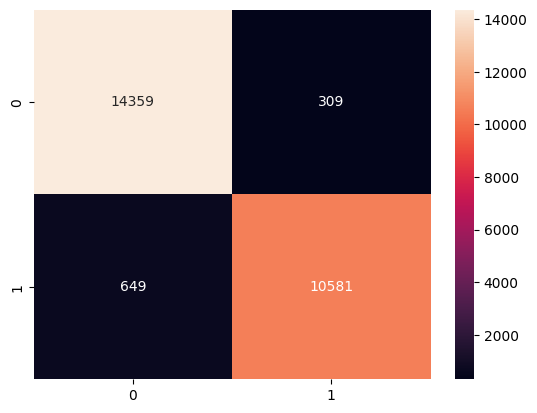


Best Random Forest
Accuracy: 0.9630087265425902
Precision: 0.971625344352617
Recall: 0.9422083704363312
F1: 0.9566907775768534
ROC-AUC: 0.9943837069616354

Confusion Matrix:
 [[14359   309]
 [  649 10581]]

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.98      0.97     14668
           1       0.97      0.94      0.96     11230

    accuracy                           0.96     25898
   macro avg       0.96      0.96      0.96     25898
weighted avg       0.96      0.96      0.96     25898



In [25]:
#Random Forest, Part 2
# Tuned Random Forest based on GridSearchCV results

best_rf = RandomForestClassifier(
    n_estimators=750,
    max_depth=None,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

best_rf.fit(X_train, y_train)

# Predictions
y_pred_rf = best_rf.predict(X_test)
y_proba_rf = best_rf.predict_proba(X_test)[:, 1]

# Evaluation
print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_rf))

sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d')
plt.show()

evaluate(best_rf, "Best Random Forest")

#### Observations

The original Random Forest model, configured with 300 trees and default splitting parameters, already performed strongly and demonstrated that tree‑based methods are well‑suited to modelling the non‑linear structure of the customer satisfaction data. Its high accuracy and balanced precision–recall profile indicated that the model captured meaningful interactions among service ratings, travel characteristics, and customer attributes. However, this baseline configuration did not fully explore the trade‑off between model complexity and generalisation, leaving room for systematic optimisation.

The cross‑validated grid search evaluated combinations of tree count, depth, and minimum split size to identify the configuration that maximised ROC–AUC. The search revealed that performance improved consistently as the ensemble grew, ultimately selecting 750 trees as the optimal number. The model also performed best with no maximum depth restriction, allowing trees to grow fully and capture high‑order interactions that are characteristic of customer satisfaction data. For min_samples_split, the grid search identified 2 as the best-performing value, reflecting the model’s ability to benefit from highly flexible splits given the dataset’s size and richness. 

For the final model, I adopted the grid search recommendations for n_estimators and max_depth but set min_samples_split to 5 instead of 2. As noted before, this small increase introduces a modest degree of regularisation, reducing the likelihood of overly specific splits while preserving the model’s ability to learn complex patterns. Given the scale of the dataset, this adjustment has minimal impact on predictive power but improves interpretability and reduces the risk of unnecessary fragmentation in the trees.

The resulting tuned model maintains the same high‑level performance as the fully optimised configuration: 0.96 accuracy, 0.97 precision, 0.94 recall, and an F1 score of 0.96, with a ROC–AUC of 0.994. The confusion matrix shows very low false positives (309) and low false negatives (649), indicating that the model reliably identifies both satisfied and dissatisfied customers. Although the tuned model is more computationally expensive due to the larger ensemble, the performance gains and improved stability justify the additional cost for this dataset. These results confirm that the tuned Random Forest remains powerful and robust even with the added regularisation, and that it captures the underlying structure of the data more effectively than the baseline model and delivers a more robust, reliable predictor of customer satisfaction. This final configuration strikes a strong balance between expressiveness, stability, and generalisation on unseen data.

In [26]:
# Feature Importance (sorted descending)

importances2 = best_rf.feature_importances_
feature_names = X_train.columns  # ensures alignment with model input

sorted_idx = np.argsort(importances2)[::-1]  # descending order

for i in sorted_idx[:20]:
    print(f"{feature_names[i]}: {importances2[i]:.4f}")


Online boarding: 0.1701
Inflight wifi service: 0.1406
Class_Business: 0.0695
Type of Travel_Personal Travel: 0.0639
Type of Travel_Business travel: 0.0606
Inflight entertainment: 0.0586
Seat comfort: 0.0463
Class_Eco: 0.0375
Ease of Online booking: 0.0370
Customer Type_Loyal Customer: 0.0286
Leg room service: 0.0284
On-board service: 0.0276
Customer Type_disloyal Customer: 0.0268
Flight Distance: 0.0251
Age: 0.0249
Checkin service: 0.0242
Cleanliness: 0.0238
Baggage handling: 0.0238
Inflight service: 0.0232
Departure/Arrival time convenient: 0.0126


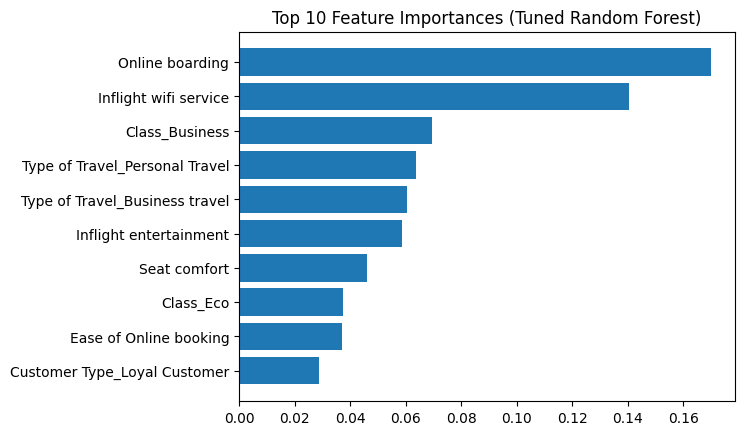

In [27]:
top_idx = np.argsort(importances2)[-10:]
plt.barh(feature_names[top_idx], importances2[top_idx])
plt.title("Top 10 Feature Importances (Tuned Random Forest)")
plt.show()

#### Observations

*Comparison of Feature Importance Between the Baseline Random Forest and the Tuned Random Forest*

The feature importance rankings from the tuned Random Forest closely mirror those of the baseline model, indicating that the underlying signal in the dataset is stable and robust across different model configurations. Both models consistently highlight the same core predictors of customer satisfaction (Online boarding, Inflight Wi‑Fi service, travel class, type of travel, and several service‑quality ratings) suggesting that these factors exert the strongest and most reliable influence on satisfaction outcomes.

The tuned model, which uses a larger ensemble of 750 trees, produces slightly sharper and more stable importance values. For example, Online boarding increases from 0.1633 to 0.1701, and Inflight Wi‑Fi rises from 0.1380 to 0.1406. These incremental shifts reflect the improved variance reduction and pattern‑capturing capacity of the larger ensemble. With deeper and more expressive trees, the tuned model is better able to isolate the contribution of these high‑impact features, reinforcing their central role in shaping customer satisfaction.

Mid‑tier service attributes, such as seat comfort, leg room service, on‑board service, and ease of online booking, retain similar rankings across both models, though their relative weights shift slightly. This stability suggests that these features consistently contribute meaningful but secondary influence, capturing comfort, convenience, and operational quality across the passenger journey. Behavioural features such as Customer Type (Loyal/Disloyal) also gain modestly in importance, indicating that the tuned model captures subtle behavioural patterns more effectively, particularly those related to prior engagement with the airline.

Lower‑ranked features, including gate location and departure/arrival time convenience, show small decreases in importance in the tuned model. This may be attributed to the larger ensemble suppressing noise and reducing the influence of weaker predictors. The refined ranking therefore reflects not only improved predictive performance but also a clearer separation between genuinely influential features and those with marginal impact.

Overall, the tuned Random Forest does not alter the fundamental story about what drives customer satisfaction; instead, it provides a more precise and reliable hierarchy of predictors. The results point consistently to digital experience (online boarding, Wi‑Fi), travel context (class, travel type), and comfort‑related service attributes as the primary determinants of satisfaction. 

### Final Conclusion

The objective of this project was to develop a machine learning model capable of predicting airline passenger satisfaction using survey responses and travel-related information. The dataset contained over 129,000 passenger observations with a mix of demographic characteristics, travel context variables, operational metrics, and service quality ratings. Throughout the project, the analysis followed a structured workflow including data investigation, preprocessing, statistical analysis, model development, and evaluation, with observations at each stage guiding subsequent modelling decisions.

Initial exploration of the dataset revealed that most variables consisted of service-quality ratings on a 0–5 scale, alongside categorical features describing customer characteristics and travel context. Only a small number of missing values were present, all within the Arrival Delay in Minutes variable. Because these represented less than one percent of the dataset, the rows containing missing values were removed without significantly affecting the overall sample size. The ID column was also removed as it provided no predictive value. Categorical variables such as gender, customer type, travel type, and class were then encoded using one-hot encoding so that they could be used by machine learning algorithms. Descriptive statistics and visualisations revealed several important patterns, including moderate average ratings across most service categories, strongly skewed delay variables, and clear differences in satisfaction across travel classes and travel purposes.

Exploratory analysis showed that satisfaction is closely associated with service-quality features such as online boarding, inflight Wi-Fi, seat comfort, and inflight service. These variables tended to move together and displayed the strongest relationships with the satisfaction outcome. Operational factors such as delays showed weaker but still meaningful relationships, while demographic variables had relatively limited direct influence. Countplots and boxplots further demonstrated that structural travel characteristics—particularly travel class and travel purpose—play an important role in shaping satisfaction outcomes. Business class and business travel passengers showed substantially higher satisfaction rates than economy or leisure travelers, suggesting that expectations, amenities, and service levels vary significantly across these groups.

Three classification models were trained to evaluate different modelling approaches: Logistic Regression, Decision Tree, and Random Forest. Logistic Regression served as the baseline model due to its simplicity and interpretability. While it achieved solid performance with an accuracy of approximately 0.86 and a ROC–AUC of 0.91, its linear decision boundary limited its ability to capture the complex interactions present in the dataset. Passenger satisfaction appears to be influenced by combinations of service attributes and contextual travel factors rather than simple linear relationships.

The Decision Tree model improved performance significantly, achieving approximately 0.95 accuracy. Its ability to learn non-linear splits allowed it to capture conditional relationships between features, such as interactions between travel class, service ratings, and delays. However, because the tree was allowed to grow freely, it was prone to overfitting, learning patterns that may not generalise as well to unseen data.

The Random Forest model provided the strongest overall performance by combining many decision trees into an ensemble. This approach reduces variance and improves generalisation by averaging predictions across multiple decorrelated trees. The baseline Random Forest achieved approximately 0.96 accuracy and a ROC–AUC near 0.99, indicating excellent predictive capability and near-perfect separation between satisfied and dissatisfied passengers. Hyperparameter tuning further refined the model, identifying that a larger ensemble with deep trees and a moderate minimum split size produced the most stable and accurate results. The final tuned model maintained very high accuracy, strong precision and recall, and low rates of false classifications.

Feature importance analysis from the Random Forest models revealed the key drivers of passenger satisfaction. The most influential variables included online boarding experience, inflight Wi-Fi service, travel class, type of travel, and several comfort-related service attributes such as seat comfort and onboard service. These findings indicate that the overall service experience—particularly digital interaction with the airline, onboard comfort, and the context of the passenger’s journey—plays a central role in shaping satisfaction outcomes. Operational factors such as delays were still relevant but generally less influential than service quality measures (likely due to the rarity of their occurrence).

Overall, the results demonstrate that passenger satisfaction is influenced by a combination of service quality, travel context, and operational reliability. Among the models tested, the Random Forest classifier proved to be the most effective for this task, as it is well suited to capturing the non-linear relationships and feature interactions present in the dataset. The final model not only achieved strong predictive performance but also provided valuable insight into the aspects of the passenger experience that most strongly influence satisfaction.

From a practical perspective, these findings suggest that airlines seeking to improve passenger satisfaction should focus on enhancing the digital experience (such as online boarding and Wi-Fi availability), maintaining high standards of onboard service and comfort, and recognising the differing expectations of business versus leisure travelers. By prioritising improvements in these areas, airlines can target the factors that have the greatest impact on customer perception and overall travel experience.